# Getting started with MOFA-FLEX

MOFA-FLEX is a framework for factor analysis of multimodal data, with a focus on single-cell omics, representing an observed data matrix $\mat{Y}$ as a sum matrices $\mat{X}_i$, each of which is a product of a low-rank factor matrix $\mat{Z}_i$ and a low-rank weight matrix $\mat{W}_i$: $\mat{Y} \approx \sum_{i=1}^T\mat{Z}_i \mat{W}_i$.
In the simplest and most common case, there is only one additive term, i.e. $T = 1$.
In this case, MOFA-FLEX is essentially a synthesis of MOFA{cite:p}`pmid29925568,pmid32393329`, MEFISTO{cite:p}`pmid35027765`, MuVI{cite:p}`pmlr-v206-qoku23a`, nonnegative matrix factorization, and NSF{cite:p}`pmid36587187`.
It natively supports [MuData](https://mudata.readthedocs.io) and [AnnData](https://anndata.readthedocs.io) objects, integrating into the wider [scverse](https://scverse.org) ecosystem.

For this notebook, we will use the [pbmc3k dataset by 10x Genomics](https://www.10xgenomics.com/resources/datasets/pbmc-from-a-healthy-donor-granulocytes-removed-through-cell-sorting-3-k-1-standard-2-0-0), conveniently packaged in the `mudatasets` package.
The dataset contains 10 000 single cells profiled with the 10x multiome assay, capturing gene expression (scRNAseq) and chromatin accessibility (scATACseq).

In [1]:
import mudata as md
import mudatasets as mds
import muon as mu
import mofaflex as mfl
import scanpy as sc
from plotnine import *

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
theme_set(theme_bw())
md.set_options(display_style="html", display_html_expand=0);

In [3]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
mdata = mds.load("pbmc3k_multiome")

■ File filtered_feature_bc_matrix.h5 from pbmc3k_multiome has been found at /home/kats/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5
■ Checksum is validated (md5) for filtered_feature_bc_matrix.h5
■ Loading filtered_feature_bc_matrix.h5...


/data/ilia/envs/famo/lib/python3.11/site-packages/mudatasets/core.py:203: UserWarning: Dataset is in the 10X .h5 format and can't be loaded as backed.
/data/ilia/envs/famo/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/data/ilia/envs/famo/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Added `interval` annotation for features from /home/kats/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5


/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:599: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.


In [5]:
mdata.var_names_make_unique()
mdata

rna,bool,numpy.ndarray,1 columns
atac,bool,numpy.ndarray,1 columns


## Preprocessing

We first perform the basic preprocessing steps outlined in the [muon tutorial](inv:muon-tutorials#/single-cell-rna-atac/pbmc10k/1-gene-expression-processing.ipynb) to remove undetected genes and poor-quality cells.

In [6]:
rna = mdata["rna"]
rna.var["mt"] = rna.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    rna, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
mu.pp.filter_var(rna, "n_cells_by_counts", lambda x: x >= 3)
mu.pp.filter_obs(rna, "n_genes_by_counts", lambda x: (x >= 200) & (x < 5000))

mu.pp.filter_obs(rna, "total_counts", lambda x: x < 15000)
mu.pp.filter_obs(rna, "pct_counts_mt", lambda x: x < 20)

atac = mdata.mod["atac"]
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
mu.pp.filter_var(atac, "n_cells_by_counts", lambda x: x >= 10)
mu.pp.filter_obs(atac, "n_genes_by_counts", lambda x: (x >= 2000) & (x <= 15000))
mu.pp.filter_obs(atac, "total_counts", lambda x: (x >= 4000) & (x <= 40000))

We further normalize the data and determine highly variable genes.
MOFA-FLEX will automatically use only the highly variable genes for the analysis.

In [7]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)

mu.atac.pp.tfidf(atac, scale_factor=1e4)
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=0.5)

mdata.update()

In [8]:
mdata

MuData object with n_obs × n_vars = 2695 × 119335
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
  2 modalities
    rna:	2636 x 21256
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'
    atac:	2450 x 98079
      obs:	'n_genes_by_counts', 'total_counts', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'

## Fitting a model

A MOFA-FLEX model is assembled from one or multiple additive terms, each of which takes parameters influencing the model.
A basic understanding of the [model](#modeldescription) is required to correctly set the parameters for a given dataset.

We will start with the simplest case of only one additive term.
There is currently one one type of additive term implemented: The [MofaFlex](#mofaflex.terms.MofaFlex) term, which is a product of two low-rank matrices $\mat{Z}\mat{W}$, as described above.
Additional term types may be added in the future.

The MofaFlex term type uses prior distributions on the factors and weights.
Available priors are listed in the [API documentation](#mofaflex.priors) and can be passed to the `factor_prior` and `weight_prior` arguments of [MofaFlex](#mofaflex.terms.MofaFlex).
Priors that do not require any mandatory arguments can be passed both as string, e.g. `weight_prior="Normal"`, and as an instance of the respective class, e.g. `weight_prior=mfl.priors.Normal()`.
Some priors, like the [InformedHorseshoe](#mofaflex.priors.InformedHorseshoe), require mandatory arguments.
These priors can only be passed as an instance, e.g. `weight_prior=mfl.priors.InformedHorseshoe(annotation_varm_key="some_key")`.

The examples above specified the same prior for all views.
Different priors for different views can be specified by passing a dictionary to the corresponding argument.
For example,`weight_prior={"view_1": "Normal", "view_2": "SpikeSlab", ("view_3", "view_4")="Horseshoe"}` uses the Normal prior for view `view_1`, the spike and slab prior for view `view_2`, and the Horseshoe prior for views `view_3` and `view_4`.
The same applies to factor priors and groups.

For this introductory tutorial, we will use the default Normal prior on the factors and the spike and slab prior on the weights

In [9]:
model = mfl.terms.MofaFlex(n_factors=15, weight_prior="SpikeSlab")

This model corresponds to a standard MOFA model.
It is an instance of the [MOFAFLEX](#mofaflex.MOFAFLEX) class.

Since we have normalized the data in the previous section, we will use a Normal (Gaussian) likelihood.
In general, a negative binomial likelihood is more appropriate for unnormalized count data.
Similar to how the priors can be specified either as strings or instances of the respective classes, likelihoods for all or individual views can be given as strings or instances of [likelihood classes](#mofaflex.likelihoods) to [fit](#mofaflex.MOFAFLEX.fit).
If a likelihood class has required arguments, it can not be used with the string form.

With default settings, MOFA-FLEX will plot the number of observations in each view and group.
This can be turned off by setting the `plot_data_overview` argument to [fit](#mofaflex.MOFAFLEX.fit) to `False`.
MOFA-FLEX will also automatically save the final model after training which can later be loaded with [MOFAFLEX.load](#mofaflex.MOFAFLEX.load).
The name of the saved file can be changed using the `save_path` argument to [fit](#mofaflex.MOFAFLEX.fit).

WARNING	Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.


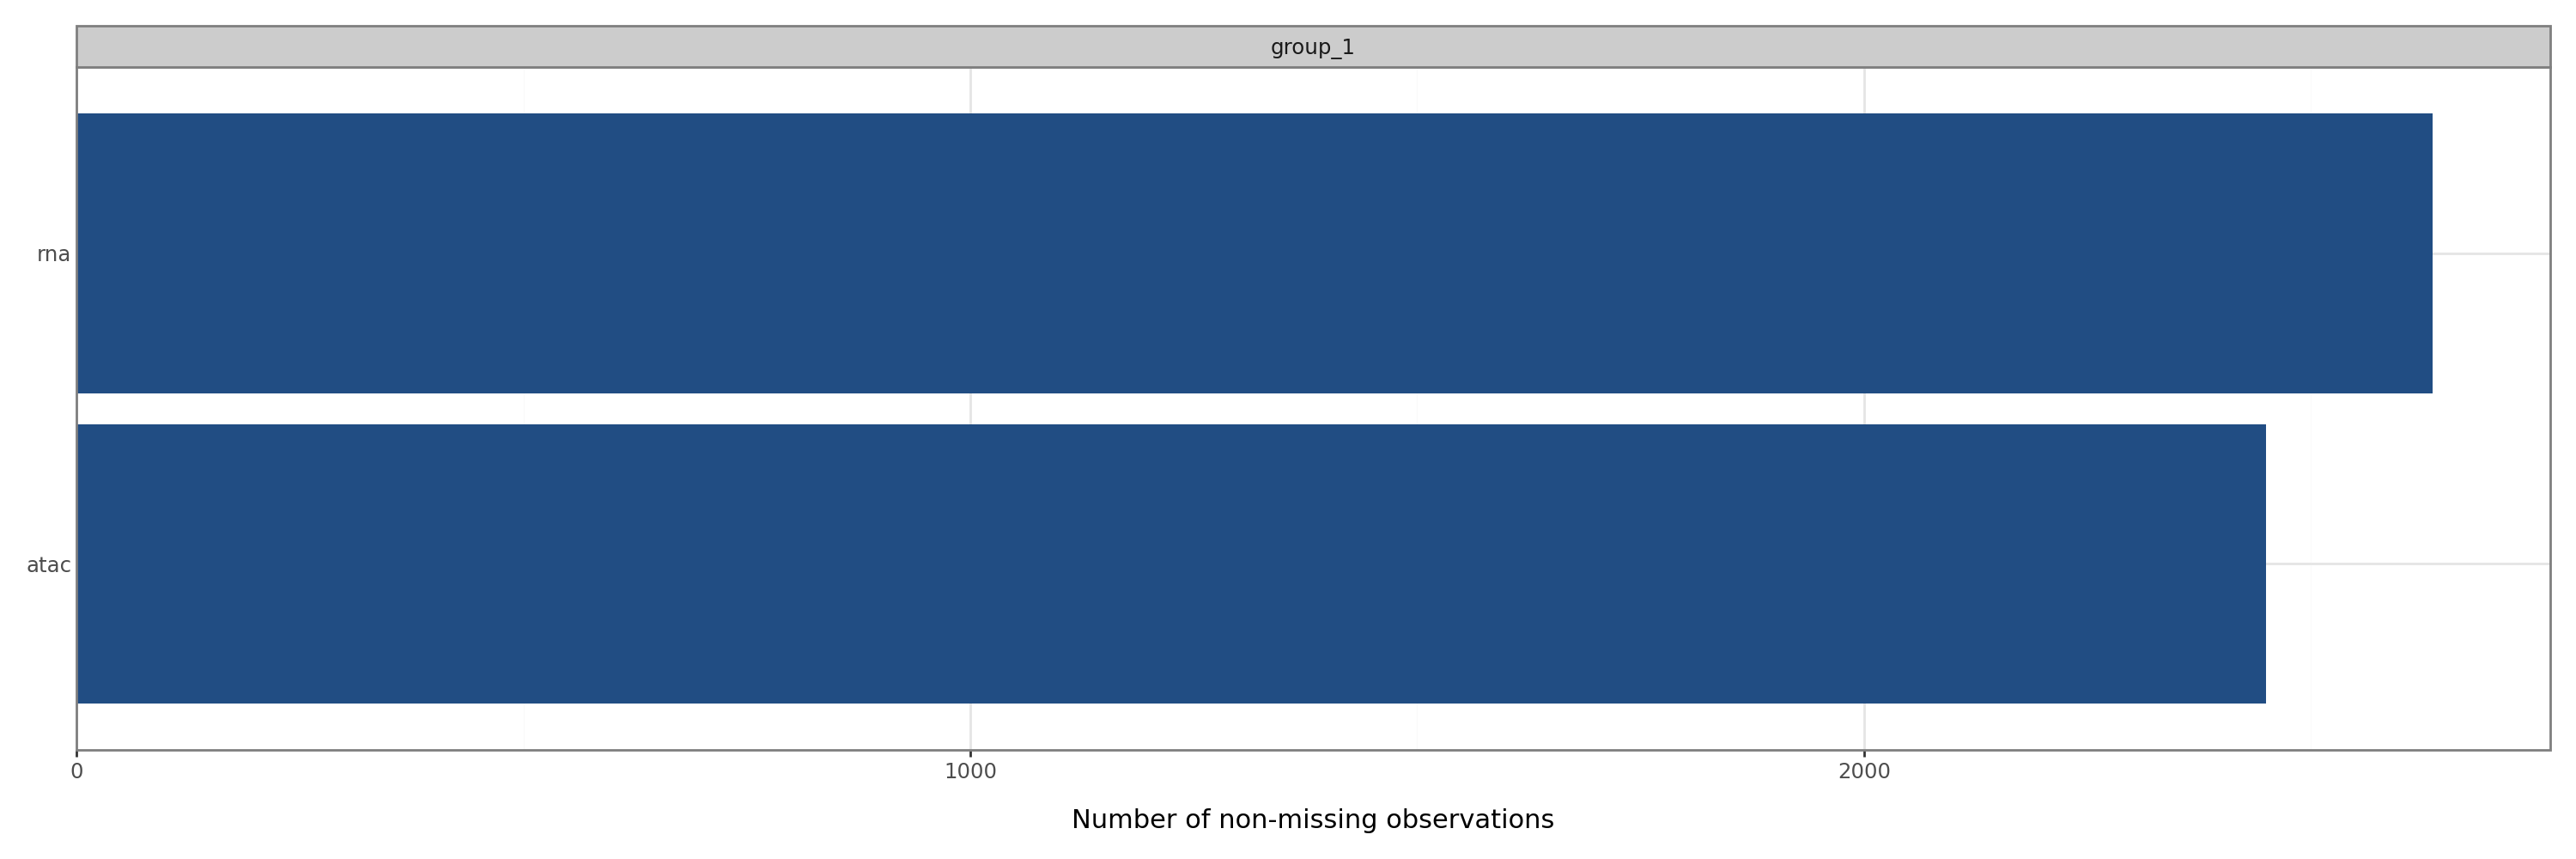

INFO	Initializing factors using 'random' method...


  0%|                                                                                                         …

INFO 	 Guessed max_plate_nesting = 2
INFO	Training converged after 1995 epochs.
INFO	Saving results to mofaflex_20260223_133215.h5...


In [10]:
model.fit(mdata, likelihoods="Normal", batch_size=1000, seed=42)

We can plot the loss curve to get an overview of the training process:

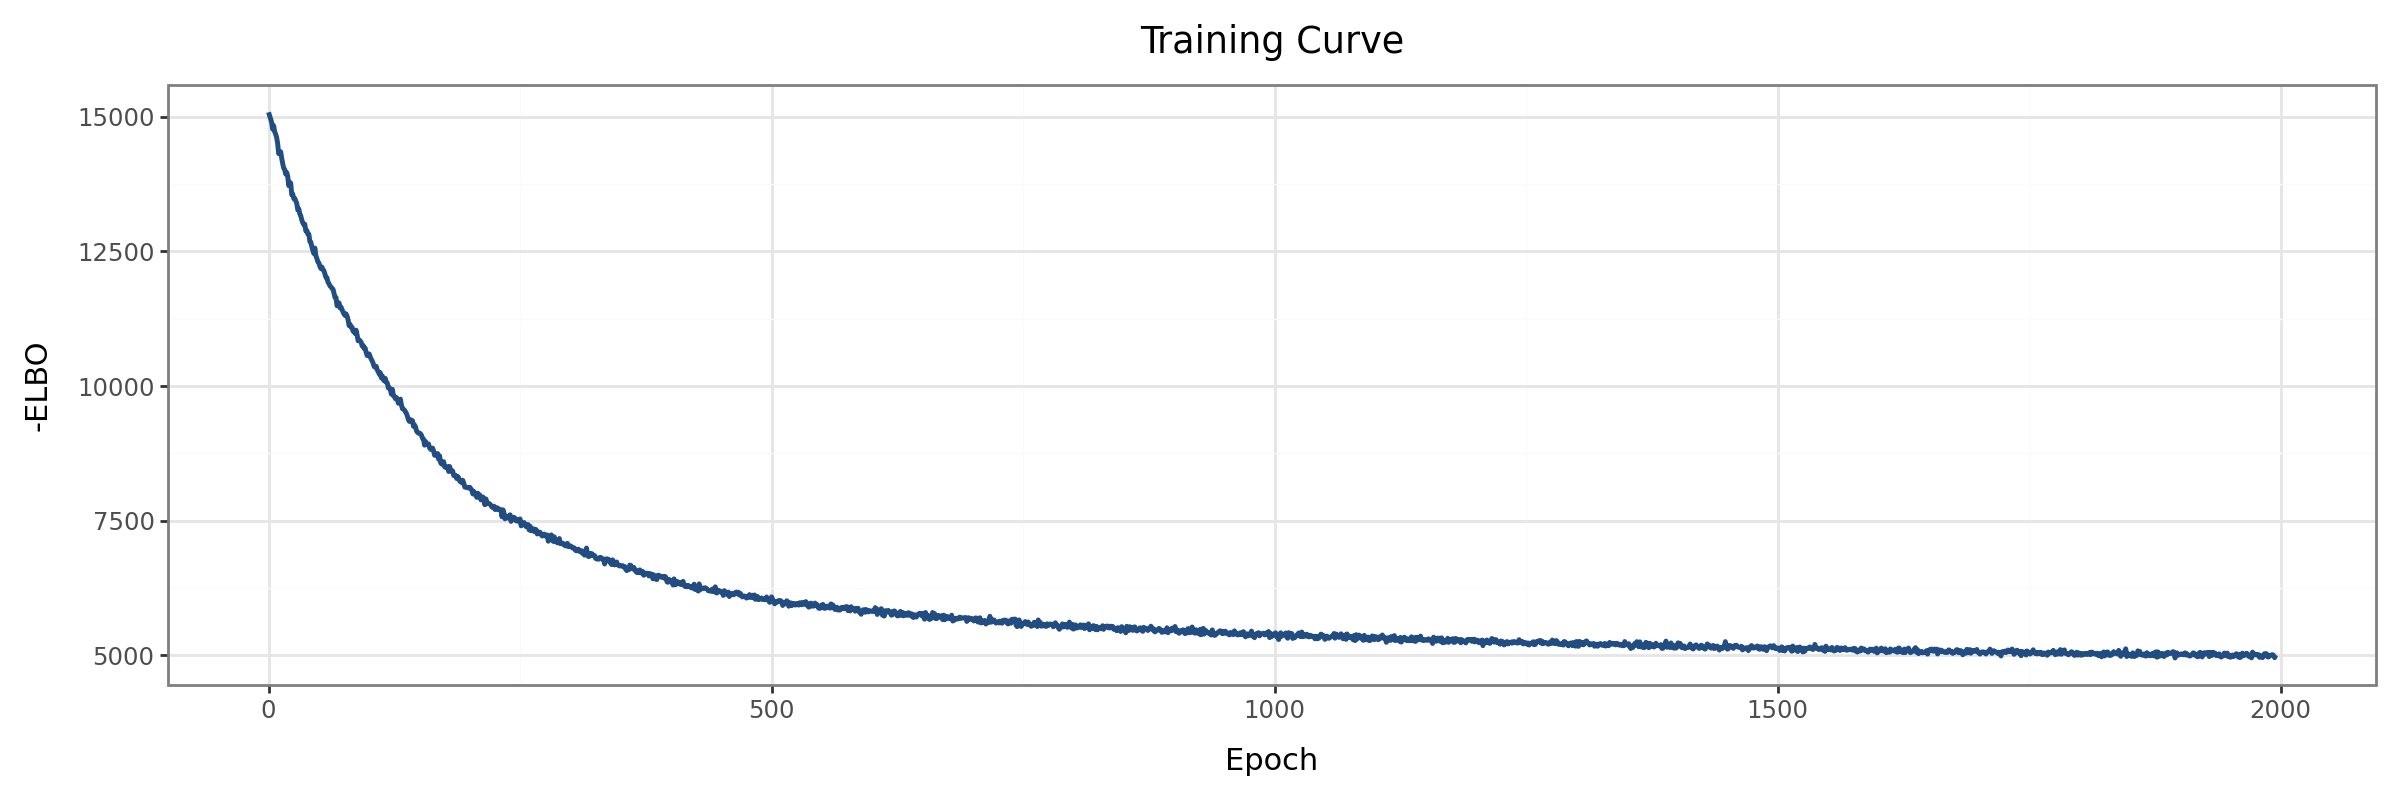

In [11]:
mfl.pl.training_curve(model)

## Analysing the model
The trained model can now be analysed to assess its quality and discover relevant biology.
Most relevant information is contained in the addtive terms themselves, as can be seen from the [API documentation](#mofaflex.terms.MofaFlex).
Because having only one term in the model is so common, this case is handled specially: The [MOFAFLEX](#mofaflex.MOFAFLEX) object forwards requests for any attributes that it doesn't know about to its only term.
We can therefore largely ignore anything related to additive terms and simply pass the [MOFAFLEX](#mofaflex.MOFAFLEX) object to any downstream analysis function.

First, we plot the correlations between factors, which should be as low as possible: We want factors to be uncorrelated, as each factor should capture a different aspect of the data.

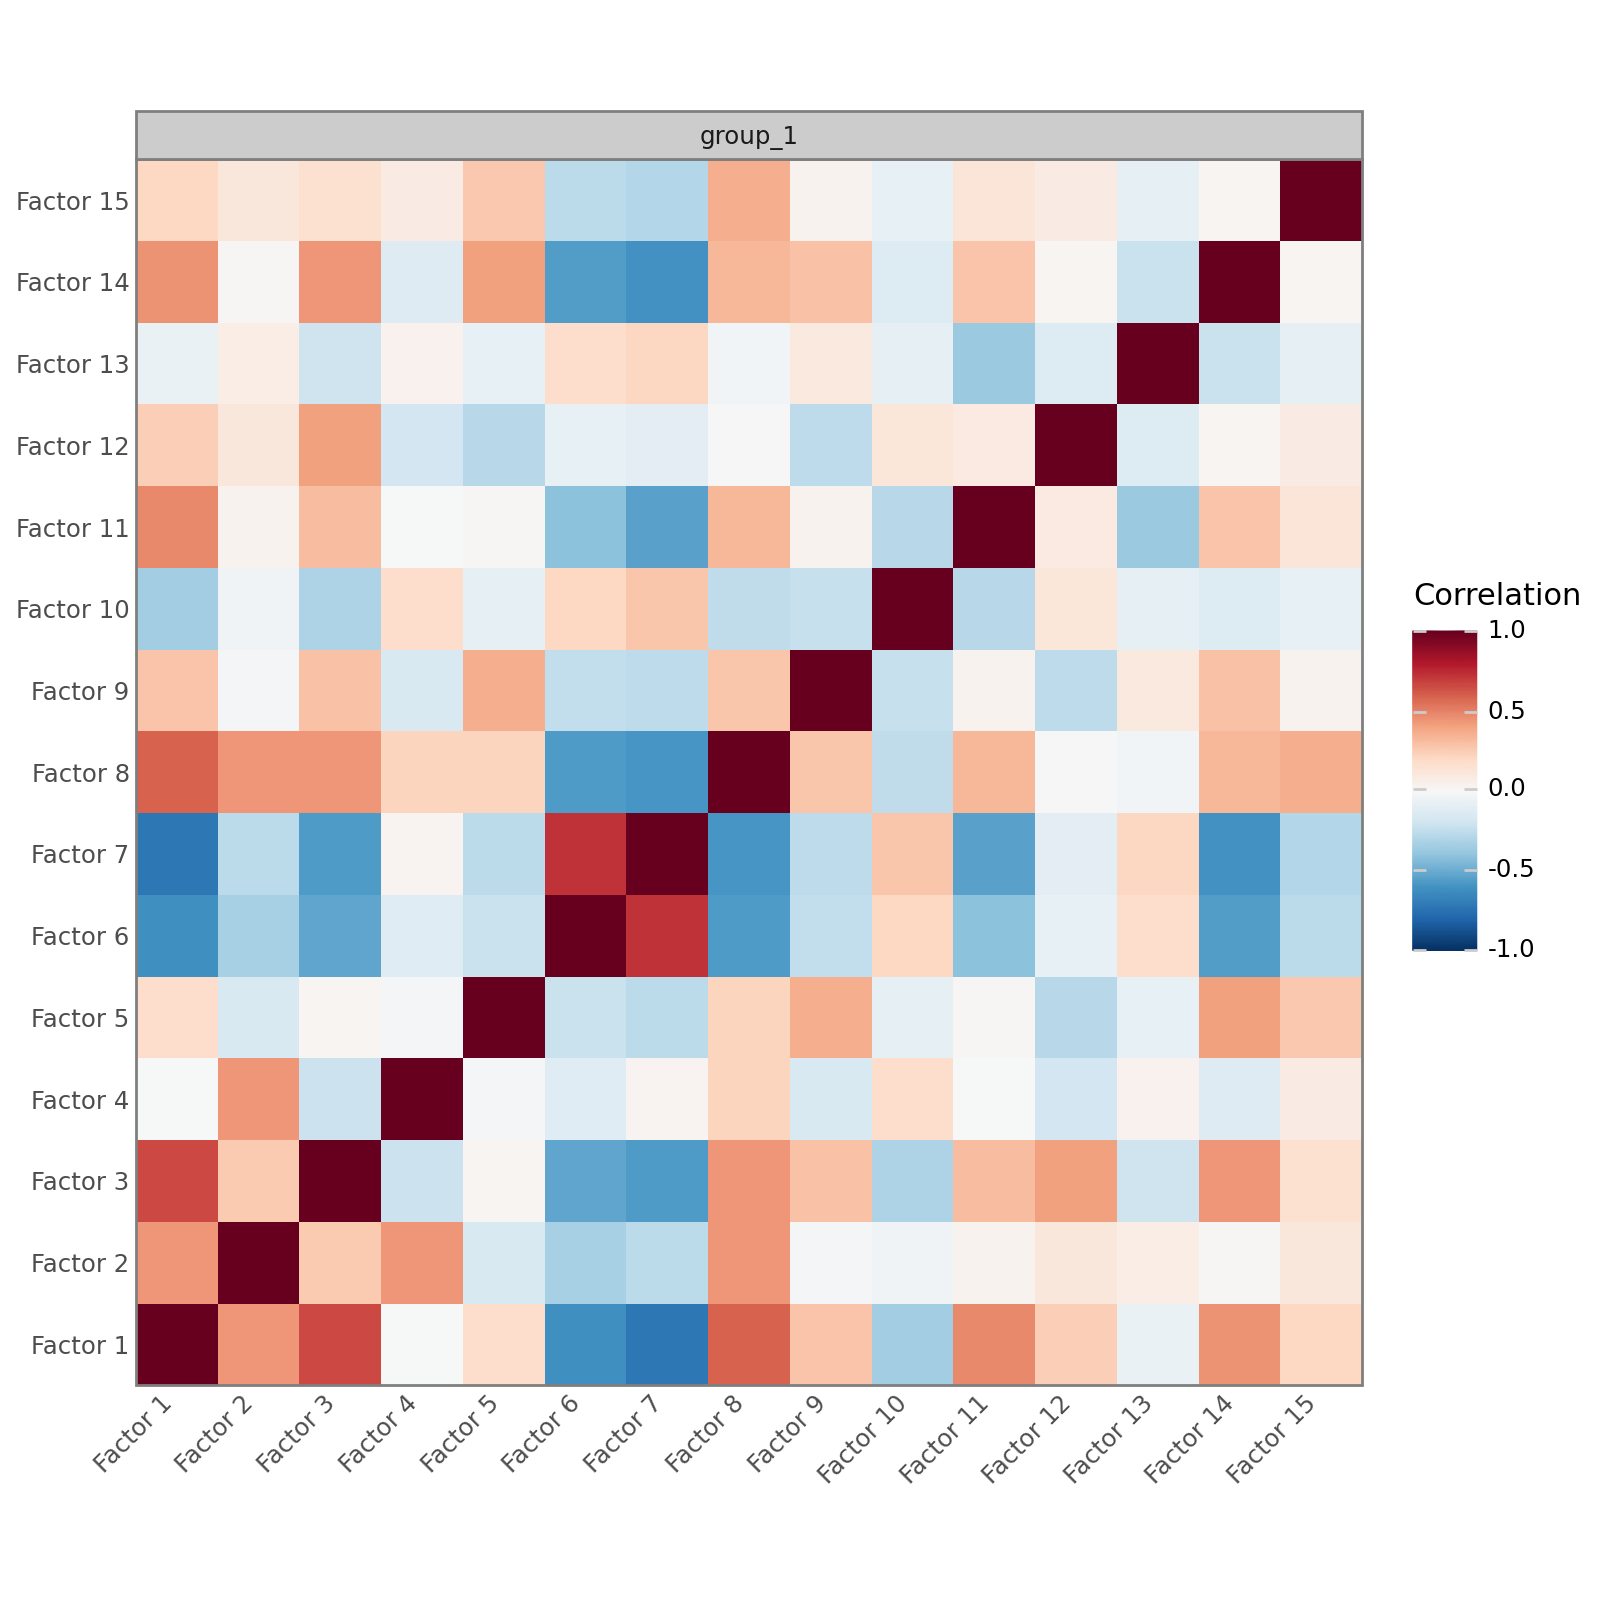

In [12]:
mfl.pl.factor_correlation(model)

This is not great, but good enough for this introduction.
We can now plot the fraction of variance in the data explained by each factor to determine the most important factors.
Note that for non-Normal likelihoods, these values are approximate.

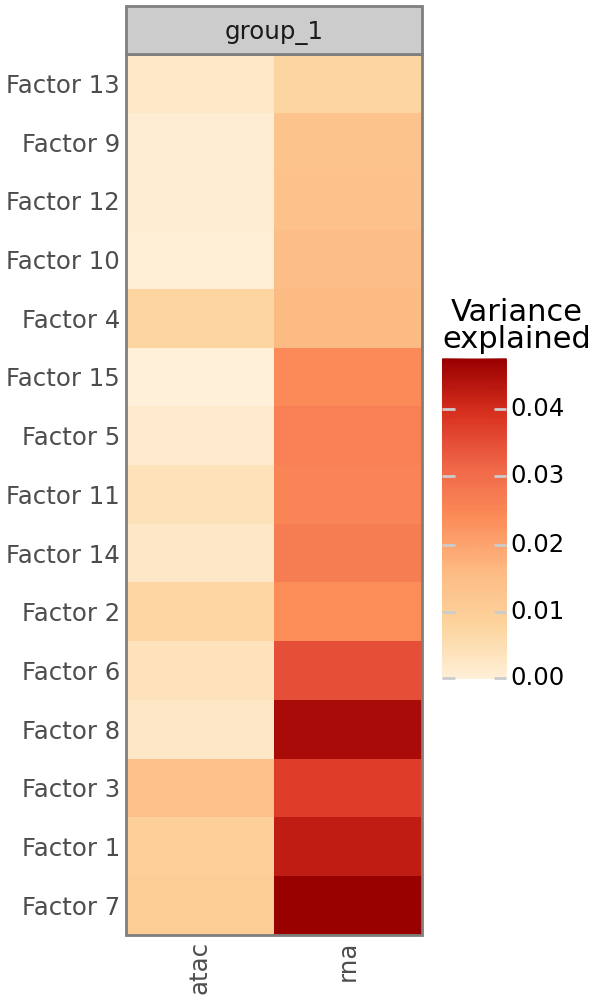

In [13]:
mfl.pl.variance_explained(model)

We can plot the most important genes per factor to get an idea of what each factor represents.
This plot aggregates over all views.

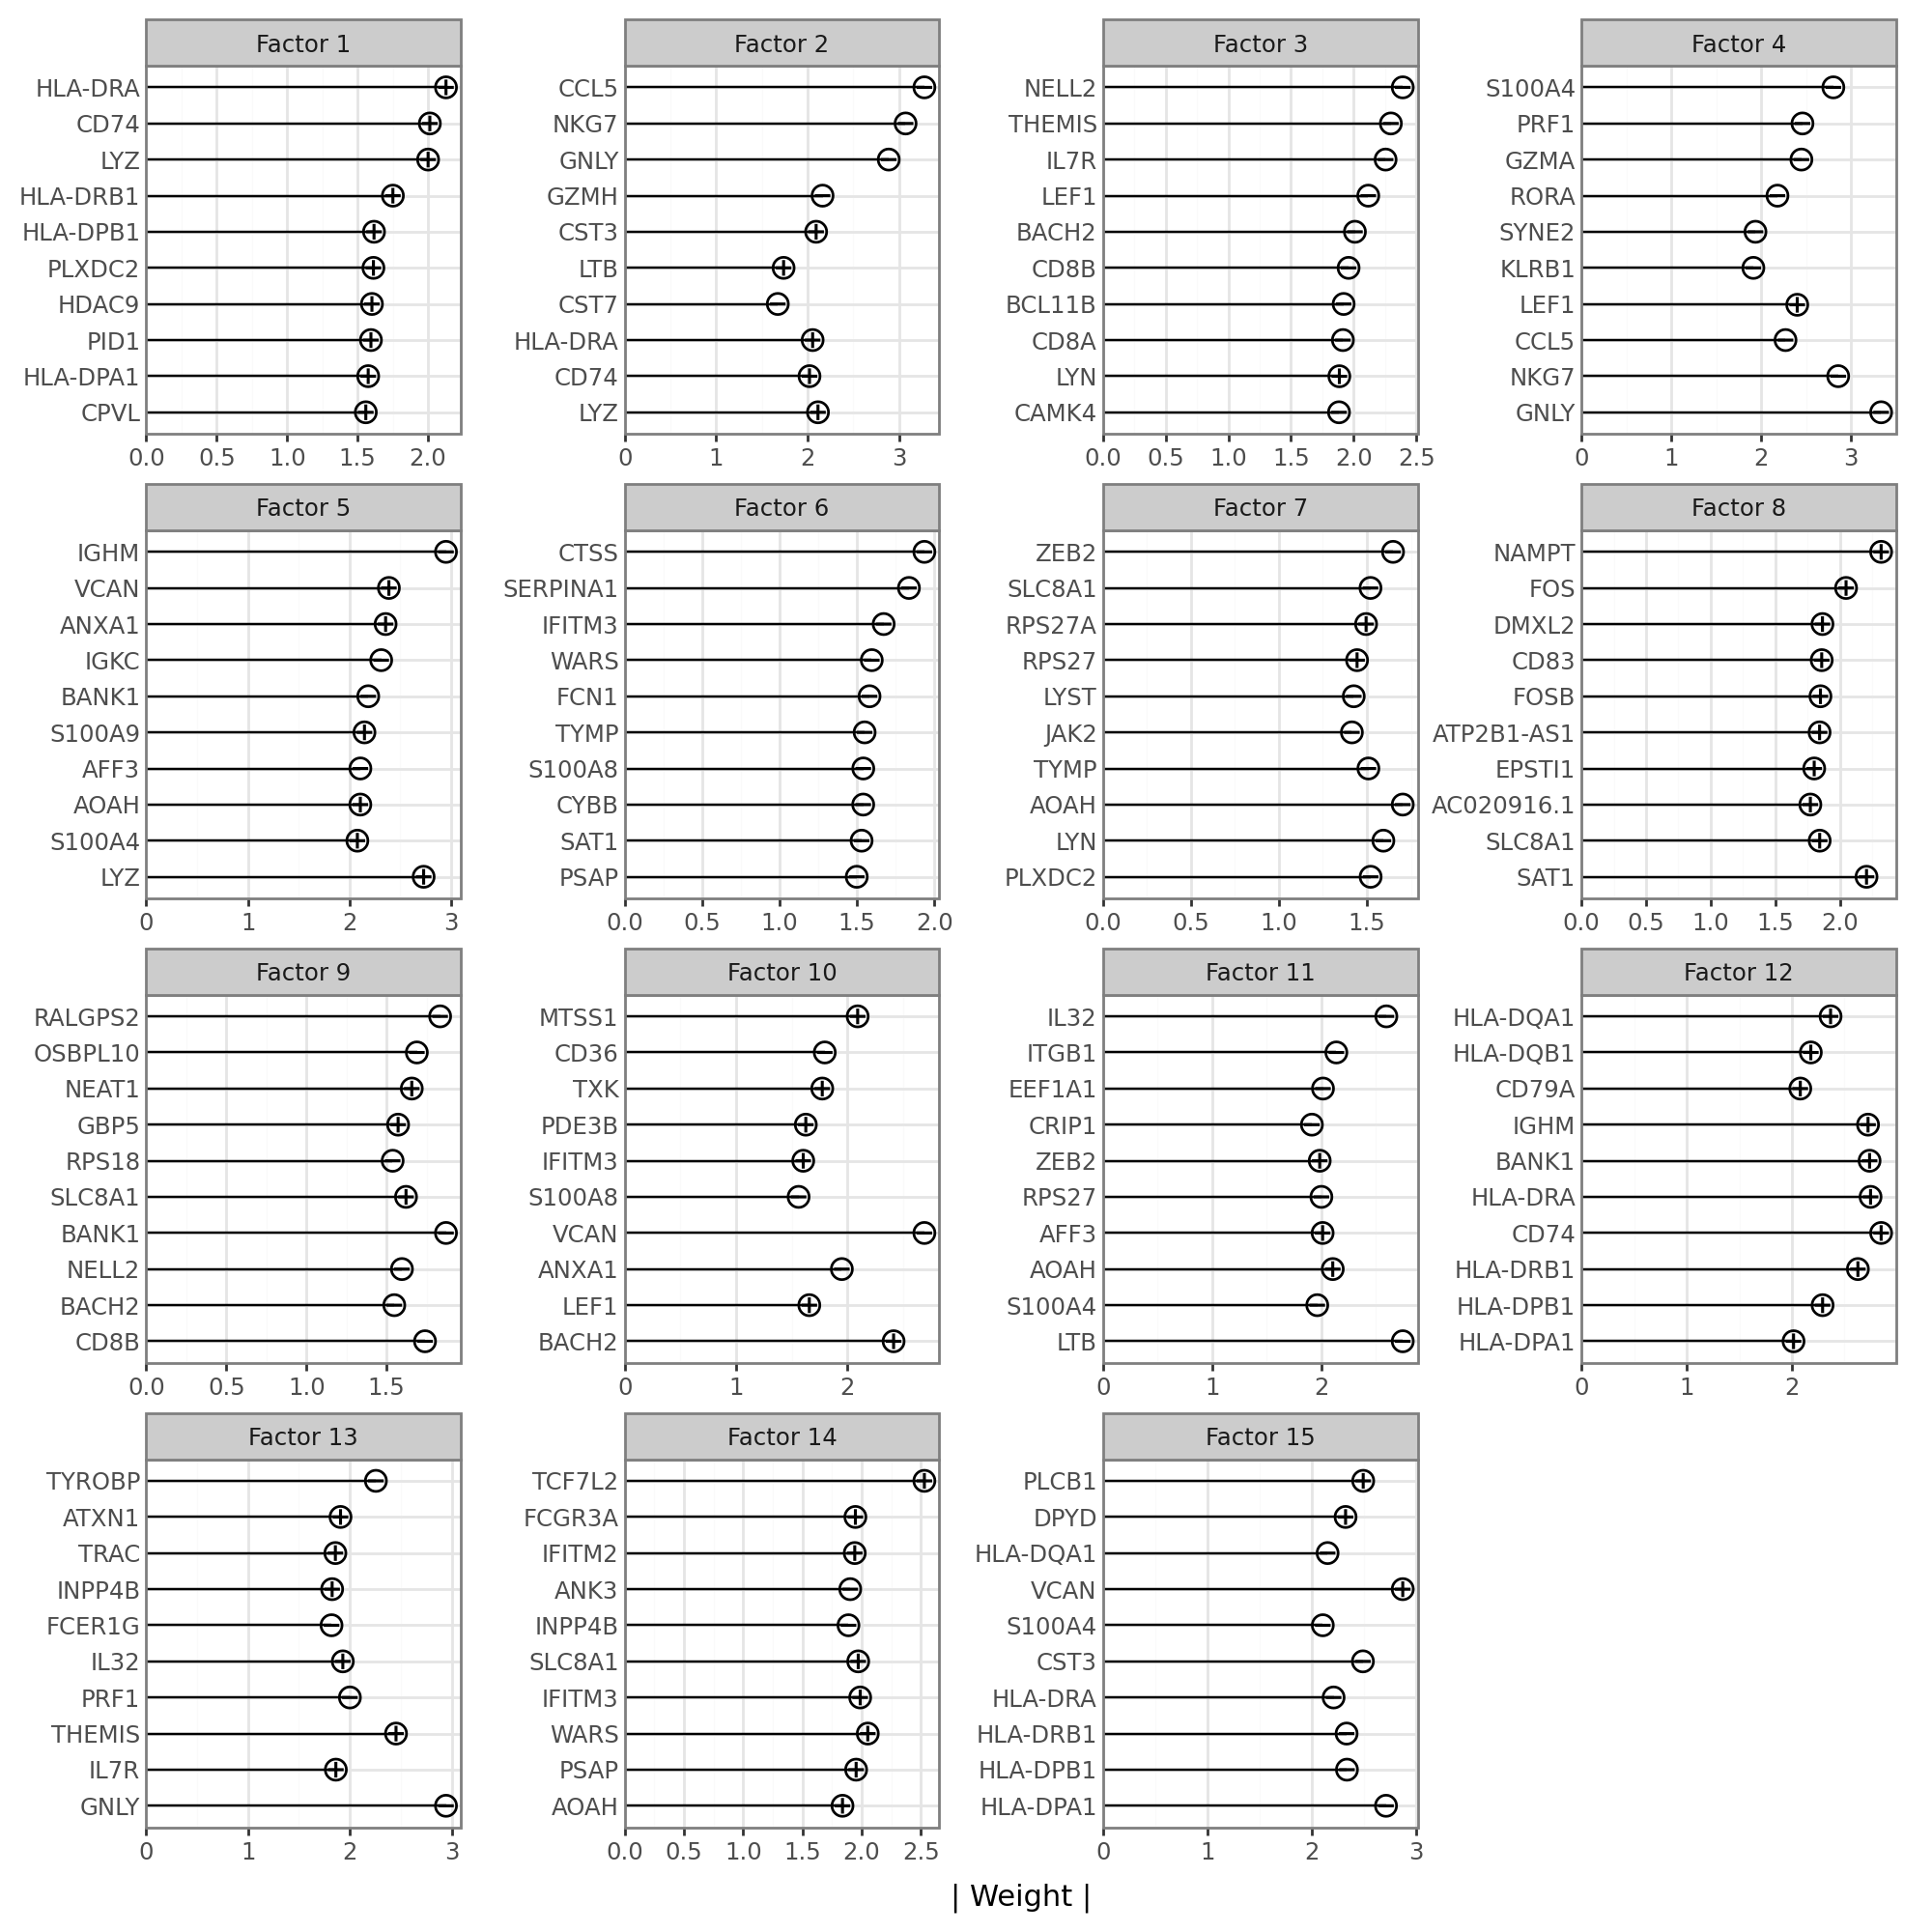

In [14]:
mfl.pl.top_weights(model, figsize=(10, 10))

It appears that the most important features are all from the RNA dataset.
We can use a different plotting function to get the top weights individually for each view.

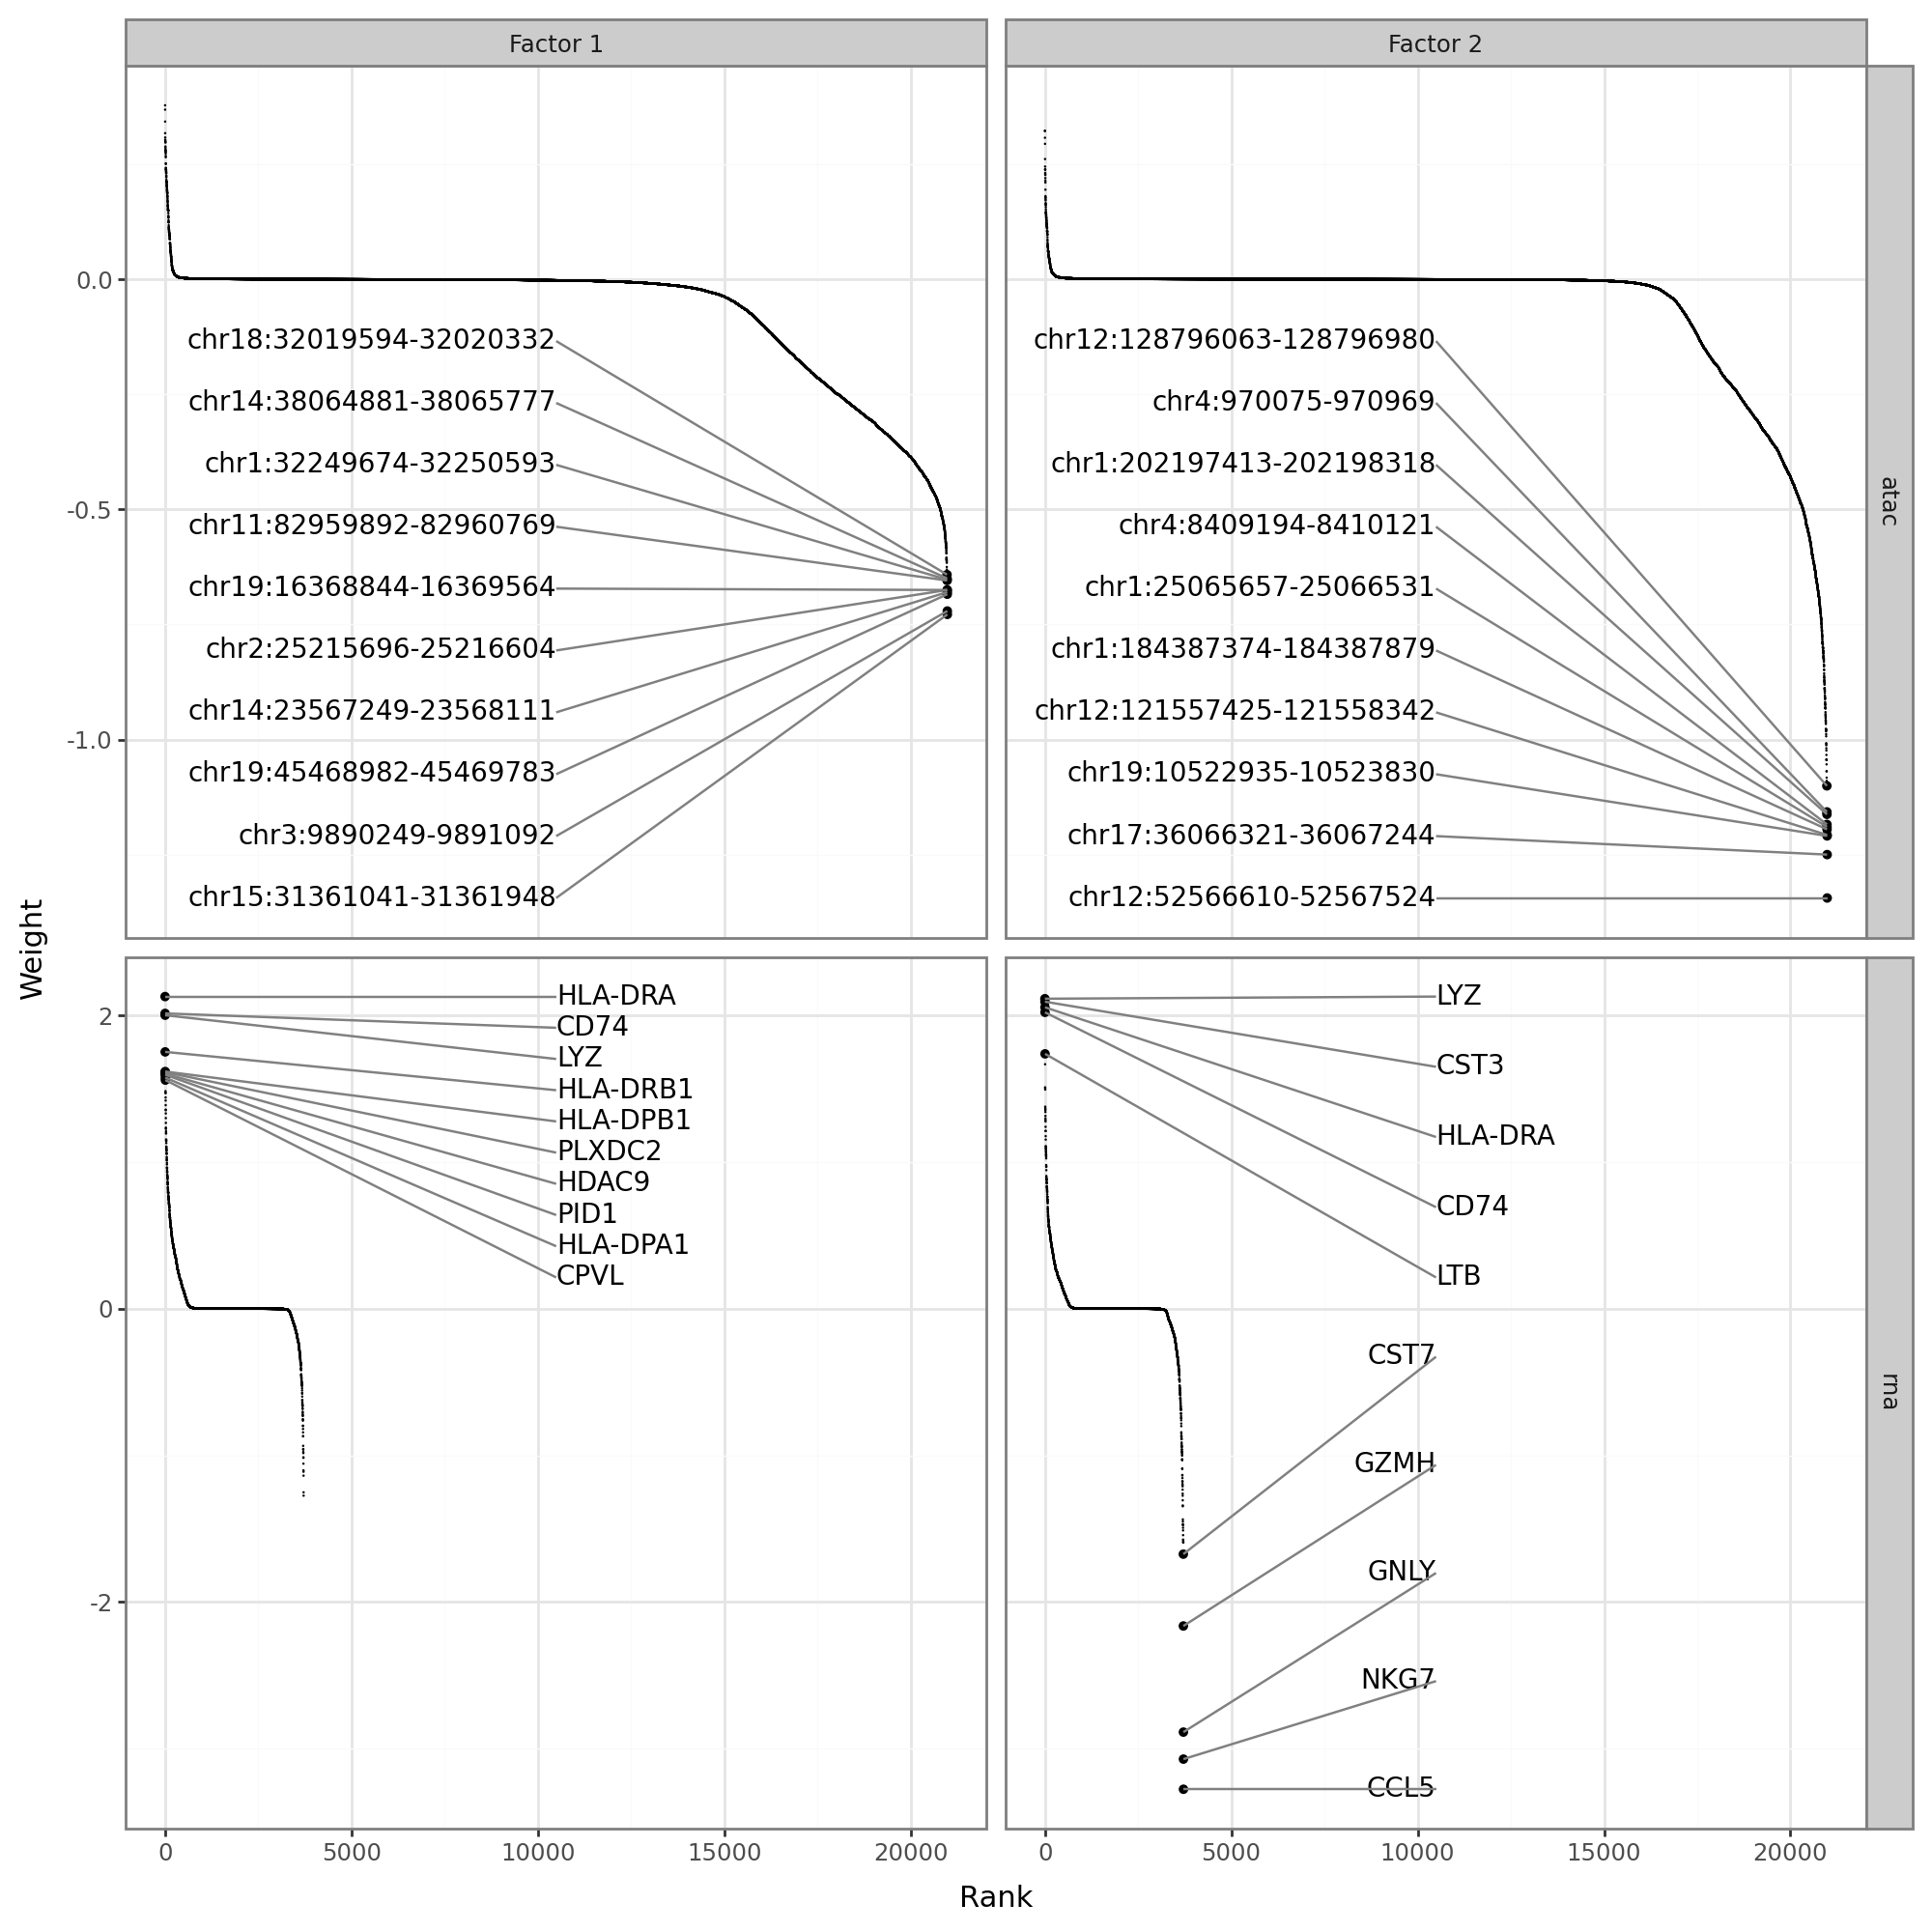

In [15]:
mfl.pl.weights(model, factors=(1, 2), figsize=(10, 10))

We can also plot factors agains each other.
This may be useful to define clusters of cells with similar factor values.

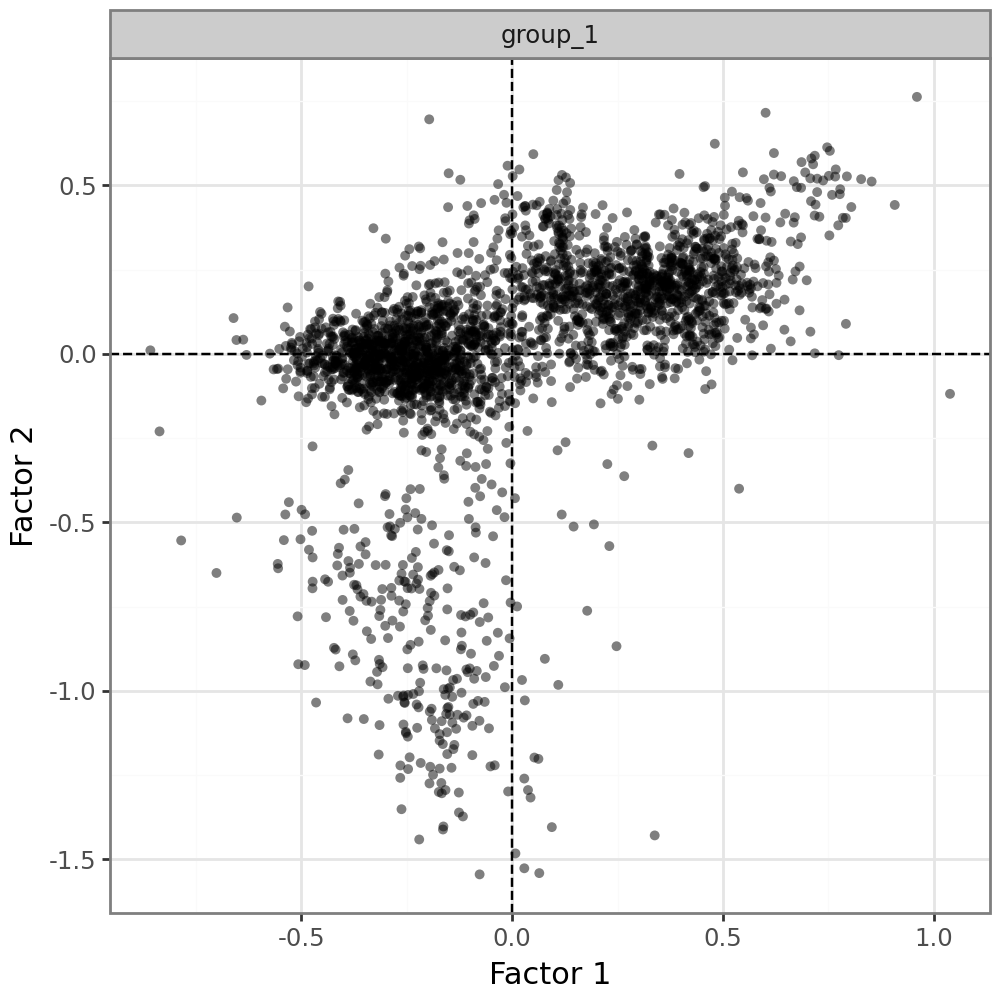

In [16]:
mfl.pl.factors_scatter(model, 1, 2, alpha=0.5)

Some priors, like the spike and slab prior we used here, provide additional, prior-specific functionality.
It is documented with the respective [prior class](#mofaflex.priors.SpikeSlab), but it is only available through the model or term objects.
For example, we can retrieve the estimated probabilites that a weight is non-zero from the spike and slab prior:

In [17]:
model.get_sparse_weight_probabilities()["rna"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
ISG15,0.907351,0.967472,0.930406,0.989911,0.996477,0.987474,0.971301,0.987840,0.997191,0.989061,0.869097,0.992749,0.908470,0.996628,0.997284
C1orf159,0.020836,0.021660,0.035837,0.030507,0.013763,0.016295,0.041932,0.032445,0.337761,0.024845,0.047659,0.150292,0.034279,0.016074,0.162518
AL390719.3,0.014695,0.008472,0.010901,0.011860,0.006212,0.012545,0.012280,0.008580,0.012701,0.009219,0.007854,0.007598,0.012279,0.009544,0.008046
TNFRSF18,0.018560,0.968644,0.020908,0.996613,0.012198,0.062231,0.022805,0.027726,0.059821,0.015497,0.982226,0.977191,0.039064,0.015577,0.012805
TNFRSF4,0.022974,0.980925,0.041207,0.995690,0.018080,0.015872,0.030083,0.015865,0.035173,0.923943,0.996998,0.990913,0.983734,0.024154,0.065391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PDZD4,0.019661,0.985020,0.013107,0.988327,0.022756,0.021707,0.007589,0.028342,0.011482,0.013092,0.013994,0.009747,0.015219,0.012465,0.012936
SLC10A3,0.014703,0.009161,0.010335,0.023204,0.020582,0.014217,0.009556,0.010545,0.009974,0.010174,0.009625,0.009961,0.064897,0.011346,0.012347
MTCP1,0.015480,0.017789,0.011080,0.024393,0.013375,0.013496,0.020470,0.016989,0.015864,0.017766,0.019190,0.021110,0.019990,0.025528,0.012766
BRCC3,0.832569,0.036314,0.044227,0.035232,0.019139,0.021913,0.023558,0.021601,0.030561,0.020681,0.064110,0.029122,0.016254,0.021355,0.022014


Of course, MOFA-FLEX does not and cannot provide all imaginable analysis functions.
It thus provides methods to access the factor and weight values, such that they can be used for manual analysis.

In [18]:
weights = model.get_weights()
factors = model.get_factors()

weights["rna"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
ISG15,-0.307310,0.147454,-0.168437,-0.548156,0.550673,-0.615919,-0.209126,0.759273,0.692284,0.353094,-0.180655,0.501951,-0.212744,0.691283,-1.386797
C1orf159,-0.000466,0.000449,-0.001714,0.001626,0.000178,0.000157,-0.001347,0.000987,-0.032292,0.000348,0.003784,-0.010668,0.001494,0.000258,0.015819
AL390719.3,-0.000667,0.000051,-0.000198,0.000128,0.000260,0.000356,0.000367,0.000019,-0.000090,-0.000123,0.000030,-0.000028,0.000026,0.000068,0.000026
TNFRSF18,-0.000911,0.157169,-0.000240,-0.537049,-0.000136,0.002771,0.000333,-0.000901,-0.006406,0.000278,-0.215397,-0.229190,-0.003172,-0.000282,0.000249
TNFRSF4,-0.000034,0.299320,-0.001279,-0.515594,-0.000279,0.000474,0.000132,-0.000084,-0.001507,-0.096456,-0.532599,-0.276027,0.099232,-0.001121,-0.002782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PDZD4,-0.000487,-0.158583,0.000009,-0.147062,0.000727,-0.000305,0.000097,-0.001088,0.000008,-0.000218,-0.000235,0.000216,0.000193,0.000226,-0.000087
SLC10A3,0.000132,-0.000037,0.000166,-0.001114,-0.000795,0.000501,0.000170,-0.000342,0.000184,-0.000159,-0.000115,0.000168,-0.002455,0.000172,-0.000367
MTCP1,-0.000035,-0.000052,-0.000117,-0.000556,-0.000222,0.000334,0.000722,0.000105,-0.000074,-0.000273,0.000549,-0.000361,0.000083,-0.000626,-0.000029
BRCC3,0.077248,-0.001735,0.001343,-0.001249,-0.000754,-0.000438,-0.000409,0.001033,0.001251,-0.000324,0.002884,-0.000354,-0.000051,-0.000116,0.000231


In [19]:
weights["atac"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
chr1:267561-268455,0.001055,0.000107,0.000382,0.000647,0.000507,-0.000404,-0.000364,0.003605,-0.000315,-0.000055,0.000534,0.000200,-0.000228,0.000254,0.000564
chr1:629484-630393,-0.029646,0.001389,0.000089,0.000714,-0.173619,0.016173,0.110926,0.000113,-0.043532,0.002735,-0.003180,0.002305,0.000511,-0.001797,0.000167
chr1:778284-779202,-0.416556,-0.002964,-0.000145,-0.000290,0.000106,0.039963,0.019213,-0.000710,0.001283,-0.000204,-0.093867,-0.000176,-0.000167,-0.042418,-0.000236
chr1:844149-845034,-0.000835,0.000119,-0.459350,0.058479,-0.000066,0.006276,0.001320,0.000291,-0.004066,0.002193,-0.001564,0.000009,0.000193,-0.001403,-0.000167
chr1:857873-858632,-0.075457,-0.000059,-0.129848,0.130800,-0.001041,0.012445,0.001186,-0.000691,-0.010941,0.002422,0.000064,-0.000653,0.000755,-0.001552,-0.000193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GL000219.1:125017-125889,-0.005248,-0.004037,-0.000345,-0.000036,-0.001405,0.000428,0.002936,-0.000609,-0.000227,0.000182,-0.000779,0.000203,-0.000119,-0.001376,-0.000422
KI270721.1:2089-2980,-0.000860,-0.000382,0.000067,-0.000019,-0.000029,0.000190,0.000234,-0.000398,-0.002710,0.000156,-0.000878,0.000301,0.000319,-0.001503,0.000112
KI270726.1:27153-28037,-0.000689,0.000280,-0.004013,0.000663,-0.000121,0.003187,0.167951,-0.000183,-0.001330,0.000599,-0.000675,-0.000075,0.007371,-0.001064,-0.000152
KI270726.1:41489-42329,-0.001672,-0.000139,-0.002346,0.000202,-0.000907,0.076016,0.087928,-0.001056,-0.005532,0.000444,-0.000063,-0.000532,0.000161,-0.005621,-0.000135


In [20]:
factors["group_1"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
AAACAGCCAAATATCC-1,-0.554957,-0.636028,-0.016920,-1.095950,0.261986,0.371856,-0.242503,-0.301752,0.080081,0.032883,0.202017,-0.029437,-0.875365,0.211991,-0.063476
AAACAGCCAGGAACTG-1,0.612035,0.286613,0.207965,0.055287,0.239285,-0.215778,-0.414638,0.159871,0.277654,0.093675,0.227588,0.188399,-0.056610,0.261375,-0.297113
AAACAGCCAGGCTTCG-1,0.354993,0.127425,0.312819,0.082485,0.288181,-0.405416,-0.373531,0.360576,0.078753,-0.483631,0.211231,0.042947,-0.014426,0.179994,0.821503
AAACCAACACCTGCTC-1,0.032957,0.366913,0.427888,-0.051962,-0.880440,0.334719,0.197149,-0.248163,-0.101071,0.163213,0.011708,0.699828,-0.173349,-0.078428,0.242243
AAACCAACAGATTCAT-1,-0.247417,-1.135546,0.035206,-0.585370,0.270555,0.243265,0.073886,-0.238663,0.012999,-0.032337,0.135770,0.174433,-0.261372,0.190698,-0.162544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTGTGCATTGTGTG-1,-0.142208,-0.039271,-0.363117,0.392965,0.006957,0.309290,0.337234,0.133889,0.069136,0.069515,0.023291,-0.076985,-0.062623,0.021563,0.079993
TTCCCACAGGCGAATA-1,0.341569,0.231984,0.340370,0.033196,0.199103,-0.229104,-0.359265,0.217055,0.106105,-0.053146,0.219174,-0.062496,-0.057537,0.245146,-0.057080
TTGCTTAGTCCTTTAA-1,0.145313,0.185044,0.316008,-0.024275,0.248887,0.097686,-0.204765,0.193208,0.095867,-0.170530,0.151687,-0.005056,-0.106132,0.142125,0.115739
TTGTCCGGTGCATTAG-1,0.315805,0.180925,0.285874,0.017694,0.162500,-0.222266,-0.414497,0.239941,0.049338,-0.081717,0.254962,0.000952,-0.045032,0.169013,0.122050


## Working with multiple additive terms

The general workflow for multiple terms is very similar to the above.
We first assemble a model object from the terms.
Note that when working with multiple terms, each term must get a unique name as its first argument. These names will be used later to identify each term during downstream analysis.

In [21]:
model = mfl.terms.MofaFlex("spikeslab", n_factors=5, weight_prior=mfl.priors.SpikeSlab()) + mfl.terms.MofaFlex("hs", n_factors=5, weight_prior="Horseshoe")

Using several terms with the same name (including the default, which is used if no name is specified) will not work:

In [22]:
model + mfl.terms.MofaFlex("hs", n_factors=3)

ValueError: Operands must have unique term names, but terms hs were found in both operands.

The model can be trained as before.

In [23]:
model.fit(mdata, likelihoods="Normal", plot_data_overview=False, batch_size=1000, seed=42)

INFO	Initializing factors using 'random' method...
INFO	Initializing factors using 'random' method...


  0%|                                                                                                         …

INFO 	 Guessed max_plate_nesting = 2
INFO	Training converged after 1966 epochs.
INFO	Saving results to mofaflex_20260223_134630.h5...


We can still access global properties of the model through the [MOFAFLEX](#mofaflex.MOFAFLEX) object:

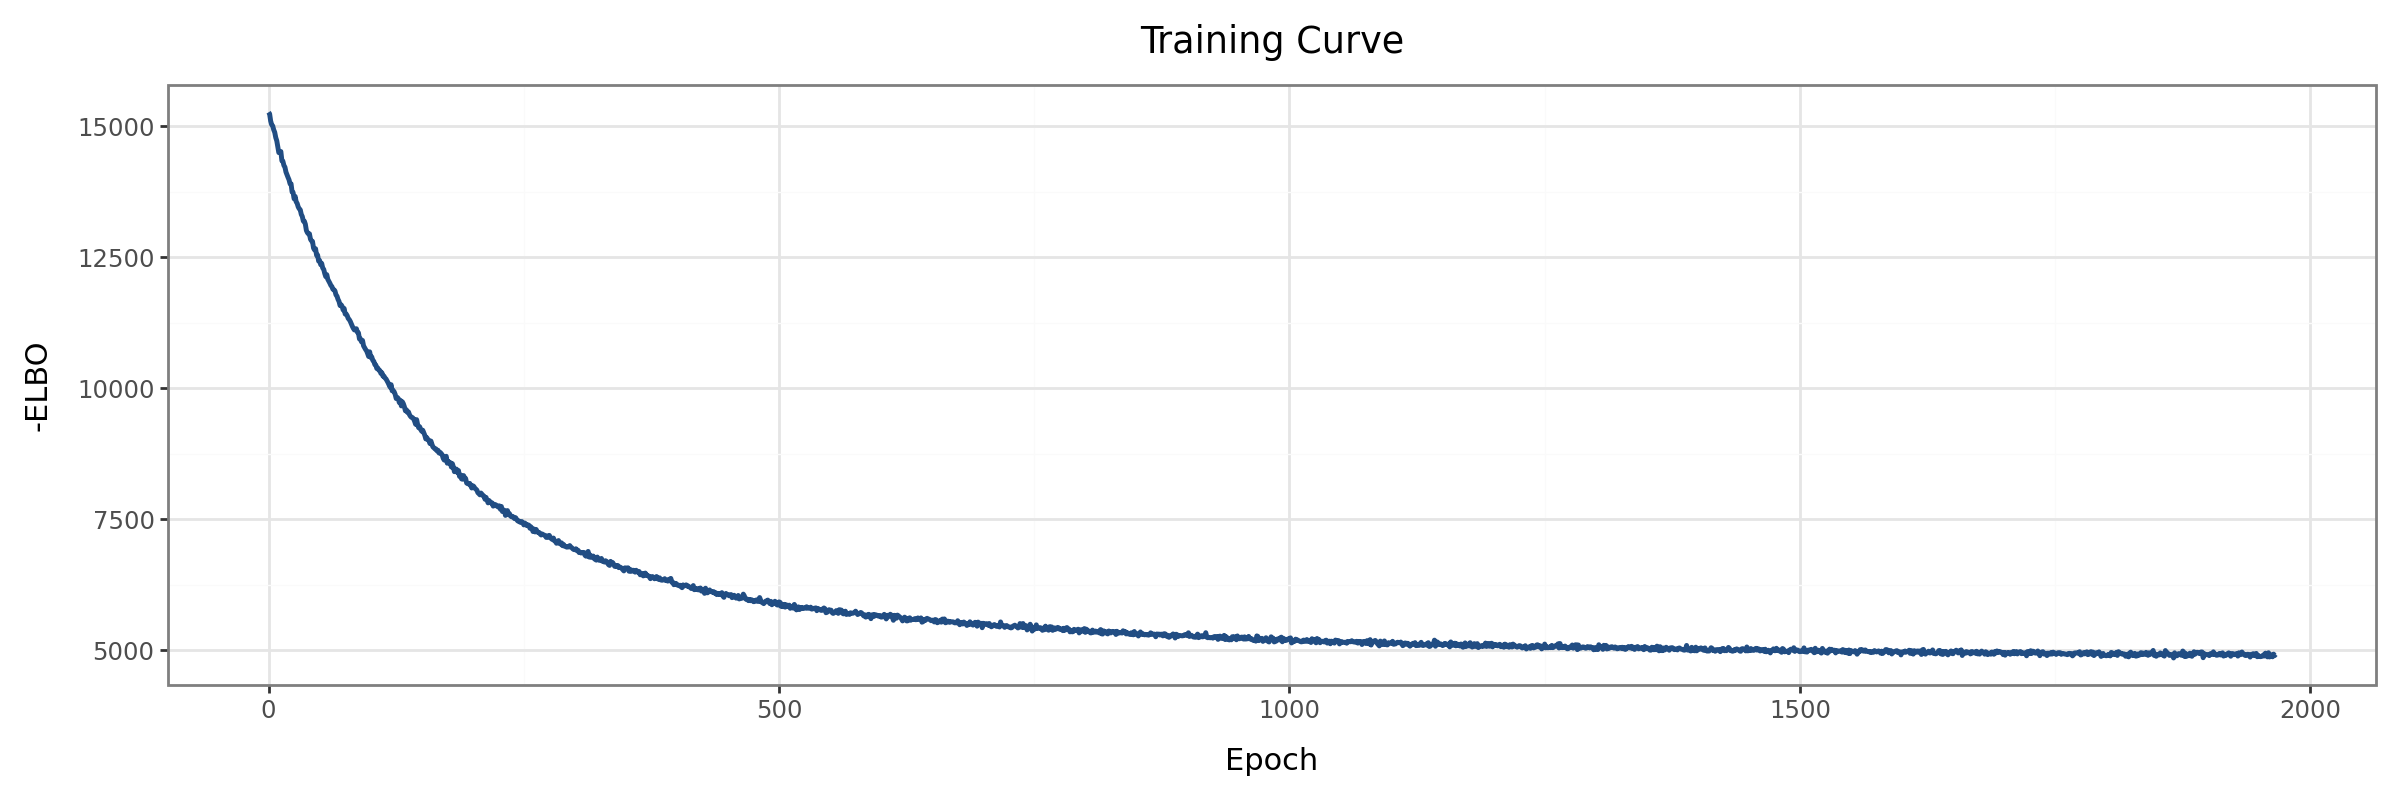

In [24]:
mfl.pl.training_curve(model)

However, each term now has its own set of factors and weights.
Terms can be accessed through `model.terms`.
For example, to plot factor correlations, individual terms need to be passed to the plotting function.

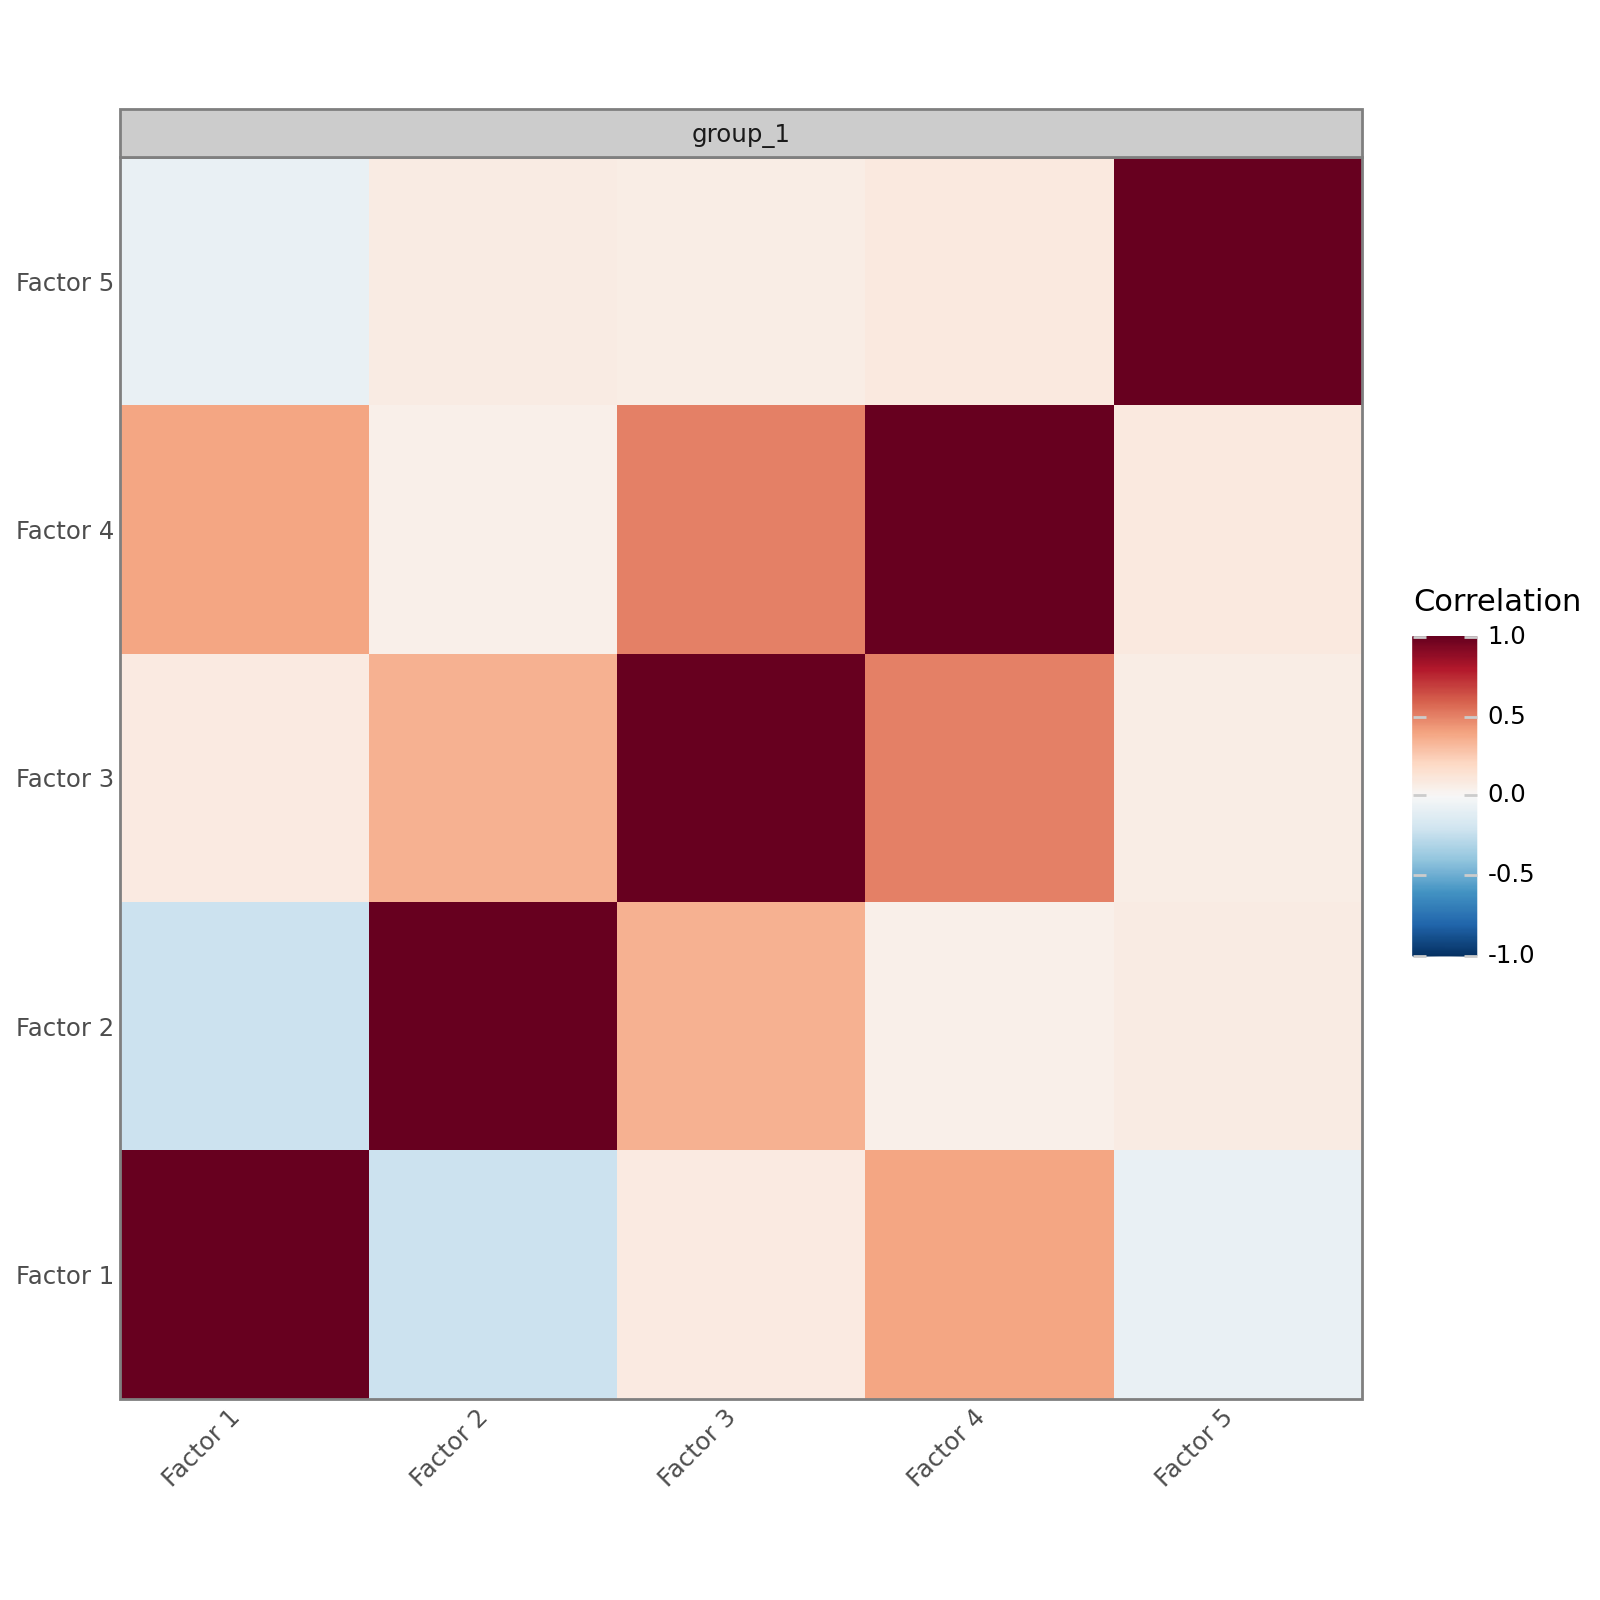

In [25]:
mfl.pl.factor_correlation(model.terms["spikeslab"])

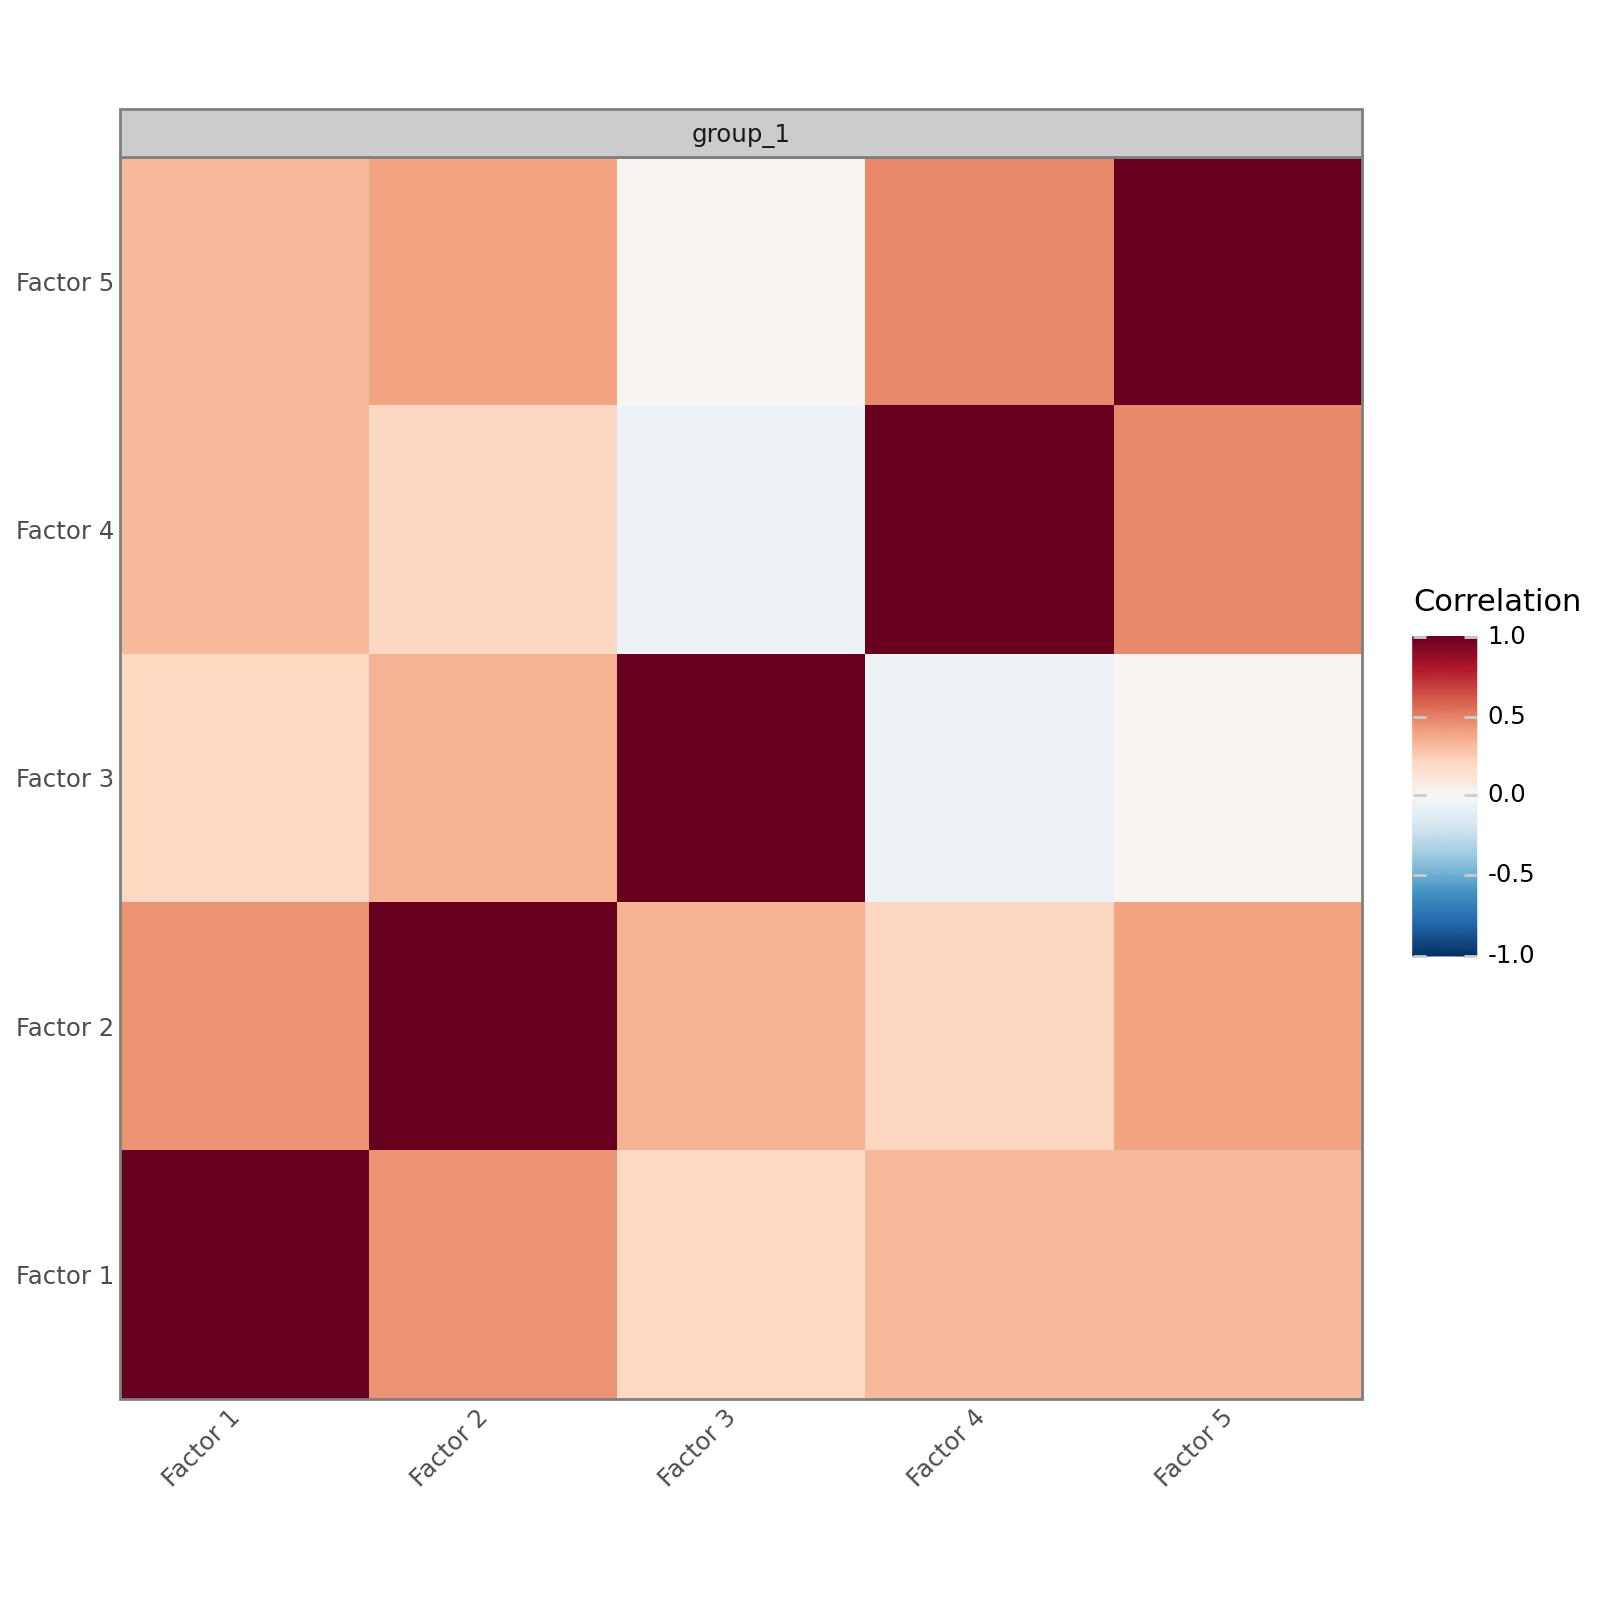

In [26]:
mfl.pl.factor_correlation(model.terms["hs"])

We can retrieve factors and weights from each term individually:

In [27]:
model.terms["spikeslab"].get_weights()["rna"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
ISG15,-0.049461,-0.237090,-0.728369,0.024563,1.160542
C1orf159,-0.014093,0.000382,-0.001730,0.000127,-0.004358
AL390719.3,0.000019,0.000224,0.000252,-0.000075,0.000195
TNFRSF18,0.000858,0.484985,0.000087,0.000328,0.000513
TNFRSF4,0.072538,0.707179,-0.000175,0.000211,0.000584
...,...,...,...,...,...
PDZD4,-0.000029,-0.000045,-0.000055,-0.000123,0.000187
SLC10A3,0.000647,-0.000532,0.000093,0.000324,0.000882
MTCP1,-0.000215,0.000174,-0.000006,0.000055,-0.000247
BRCC3,0.000124,0.000354,-0.000259,0.000462,-0.000260


In [28]:
model.terms["hs"].get_weights()["atac"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
chr1:267561-268455,0.005559,-0.020516,0.000633,-0.024448,-0.010069
chr1:629484-630393,0.028555,0.011072,0.077857,-0.030109,0.029489
chr1:778284-779202,-0.000888,0.040224,0.012272,0.159778,0.042900
chr1:844149-845034,0.206968,0.129121,0.166077,0.032500,0.044504
chr1:857873-858632,0.111969,0.118554,0.110831,-0.000843,0.002059
...,...,...,...,...,...
GL000219.1:125017-125889,0.012977,0.020929,0.000248,0.021503,0.025031
KI270721.1:2089-2980,0.005144,-0.001238,0.014928,-0.006683,0.027719
KI270726.1:27153-28037,0.033519,0.091075,0.053493,0.007624,0.042490
KI270726.1:41489-42329,0.071078,0.061600,0.012454,-0.011959,0.030795


Similarly, any prior-specific methods and properties can be accessed through the term objects:

In [29]:
model.terms["spikeslab"].get_sparse_weight_probabilities()["atac"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
chr1:267561-268455,0.018063,0.014639,0.019392,0.019494,0.022256
chr1:629484-630393,0.025180,0.013192,0.105004,0.969513,0.020776
chr1:778284-779202,0.015266,0.024299,0.990157,0.012150,0.014349
chr1:844149-845034,0.043671,0.074466,0.040380,0.018401,0.013577
chr1:857873-858632,0.015195,0.018924,0.012104,0.014554,0.015063
...,...,...,...,...,...
GL000219.1:125017-125889,0.022600,0.012115,0.013100,0.018671,0.011112
KI270721.1:2089-2980,0.012974,0.021038,0.016087,0.012599,0.013158
KI270726.1:27153-28037,0.024110,0.025697,0.021489,0.024748,0.016255
KI270726.1:41489-42329,0.016723,0.021952,0.513801,0.013328,0.015378


Adding terms to an already trained model will not work:

In [30]:
model + mfl.terms.MofaFlex(n_factors=6)

ValueError: Cannot add terms to an already trained model.